# Распознавание эмоций по изображениям лиц: FER-2013 + MobileNetV2

Этот файл - практическая часть исследования по распознаванию эмоций, в котором выполнен следующий план работы:
1. загрузить и проанализировать бенчмарк-набор данных FER-2013;
2. выполнить предобработку изображений;
3. дообучить архитектуру MobileNetV2;
4. провести три эксперимента с гиперпараметрами;
5. сравнить результаты по accuracy и macro F1-score;
6. построить кривые обучения и матрицу несоответствий.

В работе используется предобученная архитектура MobileNetV2 из библиотеки `torchvision`.

## 1. Проверка среды выполнения

Для обучения используется GPU T4 в Google Colab.


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


True
Tesla T4


## 2. Загрузка датасета FER-2013

Датасет скачивается с Kaggle через Kaggle API (посредством прикрепления файла kaggle.json)  

In [ ]:
from google.colab import files

# Загрузка kaggle.json, скачанного в настройках Kaggle API на сайте
files.upload()


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("kaggle.json"):
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API настроен")


Kaggle API настроен


In [ ]:
# Загрузка датасета FER-2013 с Kaggle
# Если архив уже скачан, команда будет пропущена
!kaggle datasets download -d msambare/fer2013


In [ ]:
import zipfile
import os

if not os.path.exists("fer2013"):
    with zipfile.ZipFile("fer2013.zip", "r") as zip_ref:
        zip_ref.extractall("fer2013")

print("Датасет распакован")


In [ ]:
import os

dataset_path = "fer2013"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        continue


## 3. Анализ датасета

Здесь проверяется количество изображений в обучающей и тестовой выборках, а также распределение самих классов.  
Это нужно, ибо в FER-2013 классы распределены неравномерно: например, класс `happy` намного больше, чем `disgust`.


In [ ]:
import os
import pandas as pd

train_dir = "fer2013/train"
test_dir = "fer2013/test"

def count_images_by_class(folder):
    counts = {}
    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

df_counts = pd.DataFrame({
    "train": train_counts,
    "test": test_counts
})

df_counts["total"] = df_counts["train"] + df_counts["test"]
df_counts


,train,test,total
angry,3995,958,4953
disgust,436,111,547
fear,4097,1024,5121
happy,7215,1774,8989
neutral,4965,1233,6198
sad,4830,1247,6077
surprise,3171,831,4002


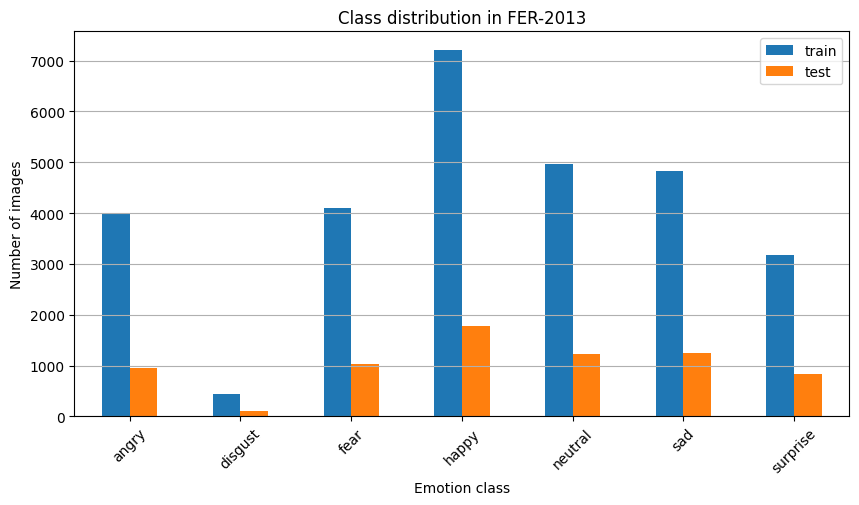

In [ ]:
import matplotlib.pyplot as plt

df_counts[["train", "test"]].plot(kind="bar", figsize=(10, 5))

plt.title("Class distribution in FER-2013")
plt.xlabel("Emotion class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


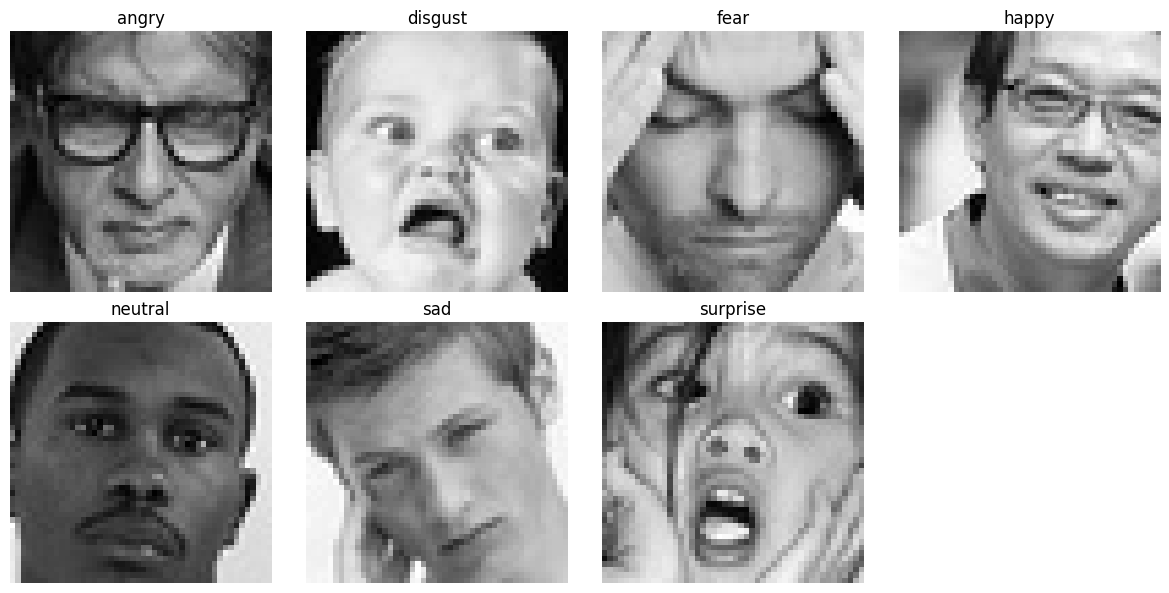

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(12, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Предобработка изображений и DataLoader

Исходные изображения FER-2013 имеют размер 48×48 и один grayscale-канал.  
MobileNetV2 ожидает на вход RGB-изображения 224×224, потому изображения приводятся к трём каналам, масштабируются и нормализуются.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "fer2013/train"
test_dir = "fer2013/test"

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train size: 28709
Test size: 7178


In [ ]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First labels:", labels[:10])


Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
First labels: tensor([6, 2, 3, 4, 3, 2, 4, 4, 6, 5])


## 5. Модель MobileNetV2

Модель берётся с предобученными весами ImageNet, а последний классификационный слой заменяется на слой с 7 выходами по числу классов эмоций, ведь изначально классификатор MobileNetV2 выдаёт 1000 классов ImageNet.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 7

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

print(model.classifier)
print("Device:", device)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 75.4MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)
Device: cuda


## 6. Функция потерь, оптимизатор и функции обучения

Используются:
- `CrossEntropyLoss` — стандартная функция потерь для многоклассовой классификации;
- `Adam` — оптимизатор;
- `accuracy` — доля правильных ответов;
- `macro F1-score` — средняя F1-мера по всем классам, полезная при дисбалансе классов.


In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")


Loss: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation/Test"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

## 7. Эксперимент 1: базовая конфигурация

**Конфигурация:**
- модель: MobileNetV2;
- learning rate: 0.001;
- weight decay: 0;
- batch size: 64;
- epochs: 10.


In [ ]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    test_loss, test_acc, test_f1 = evaluate(
        model, test_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["test_f1"].append(test_f1)

    print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}, f1: {train_f1:.4f}")
    print(f"Test  loss: {test_loss:.4f}, acc: {test_acc:.4f}, f1: {test_f1:.4f}")



Epoch 1/10


Validation/Test: 100%|██████████| 113/113 [00:16<00:00,  6.92it/s]


Train loss: 1.1788, acc: 0.5505, f1: 0.4649
Test  loss: 1.1120, acc: 0.5836, f1: 0.5244

Epoch 2/10


Validation/Test: 100%|██████████| 113/113 [00:17<00:00,  6.33it/s]


Train loss: 0.9614, acc: 0.6385, f1: 0.5844
Test  loss: 0.9998, acc: 0.6247, f1: 0.5836

Epoch 3/10


...

Train loss: 0.4709, acc: 0.8271, f1: 0.8203
Test  loss: 1.1343, acc: 0.6546, f1: 0.6302

Epoch 9/10


Validation/Test: 100%|██████████| 113/113 [00:16<00:00,  6.96it/s]


Train loss: 0.3831, acc: 0.8616, f1: 0.8557
Test  loss: 1.2499, acc: 0.6265, f1: 0.5901

Epoch 10/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.22it/s]

Train loss: 0.3354, acc: 0.8781, f1: 0.8726
Test  loss: 1.3205, acc: 0.6439, f1: 0.6162


### 7.1. Кривые обучения для эксперимента 1


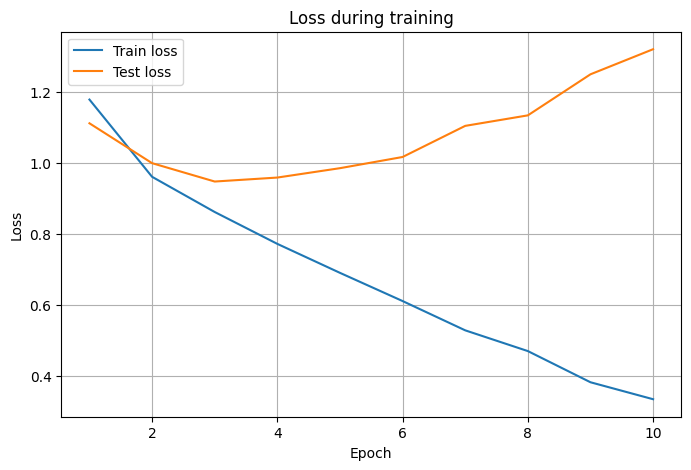

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Loss during training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


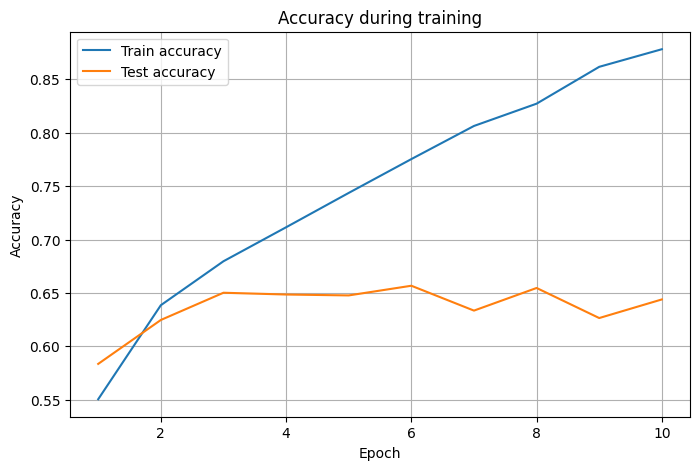

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train accuracy")
plt.plot(epochs, history["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Accuracy during training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


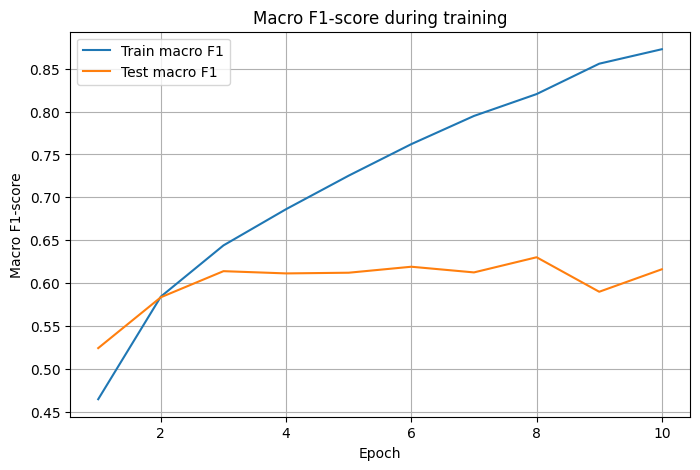

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], label="Train macro F1")
plt.plot(epochs, history["test_f1"], label="Test macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Experiment 1: Macro F1-score during training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 8. Эксперимент 2: уменьшение learning rate

**Конфигурация:**
- модель: MobileNetV2;
- learning rate: 0.0001;
- weight decay: 0;
- batch size: 64;
- epochs: 10.


In [ ]:

model_exp2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model_exp2.classifier[1] = nn.Linear(model_exp2.classifier[1].in_features, num_classes)
model_exp2 = model_exp2.to(device)

criterion_exp2 = nn.CrossEntropyLoss()
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.0001)

print("Experiment 2")
print("Model: MobileNetV2")
print("Learning rate: 0.0001")
print("Batch size: 64")
print("Epochs: 10")


Experiment 2
Model: MobileNetV2
Learning rate: 0.0001
Batch size: 64
Epochs: 10


In [ ]:
num_epochs = 10

history_exp2 = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model_exp2, train_loader, criterion_exp2, optimizer_exp2, device
    )

    test_loss, test_acc, test_f1 = evaluate(
        model_exp2, test_loader, criterion_exp2, device
    )

    history_exp2["train_loss"].append(train_loss)
    history_exp2["train_acc"].append(train_acc)
    history_exp2["train_f1"].append(train_f1)
    history_exp2["test_loss"].append(test_loss)
    history_exp2["test_acc"].append(test_acc)
    history_exp2["test_f1"].append(test_f1)

    print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}, f1: {train_f1:.4f}")
    print(f"Test  loss: {test_loss:.4f}, acc: {test_acc:.4f}, f1: {test_f1:.4f}")


Epoch 1/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.08it/s]


Train loss: 1.3833, acc: 0.4676, f1: 0.3648
Test  loss: 1.1347, acc: 0.5678, f1: 0.4561

Epoch 2/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.48it/s]


Train loss: 1.0095, acc: 0.6205, f1: 0.5211
Test  loss: 1.0262, acc: 0.6165, f1: 0.5308

Epoch 3/10


...

Train loss: 0.0897, acc: 0.9744, f1: 0.9705
Test  loss: 1.8724, acc: 0.6091, f1: 0.5876

Epoch 9/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.40it/s]


Train loss: 0.0761, acc: 0.9780, f1: 0.9758
Test  loss: 1.9267, acc: 0.6126, f1: 0.5881

Epoch 10/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.15it/s]

Train loss: 0.0728, acc: 0.9780, f1: 0.9760
Test  loss: 2.0090, acc: 0.6063, f1: 0.5820


### 8.1. Кривые обучения для эксперимента 2


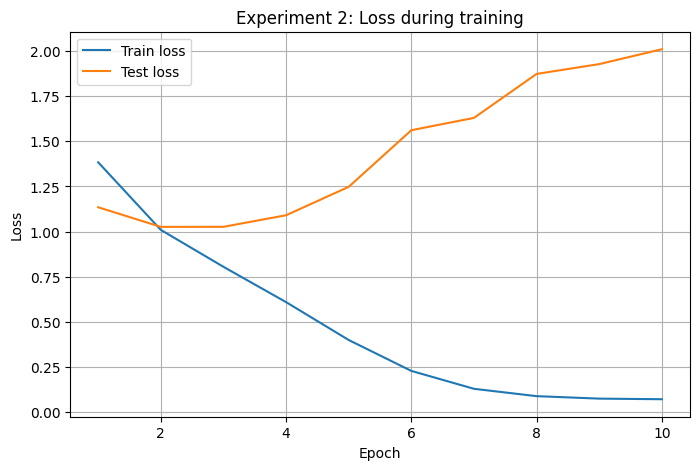

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp2["train_loss"], label="Train loss")
plt.plot(epochs, history_exp2["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: Loss during training")
plt.legend()
plt.grid(True)
plt.show()

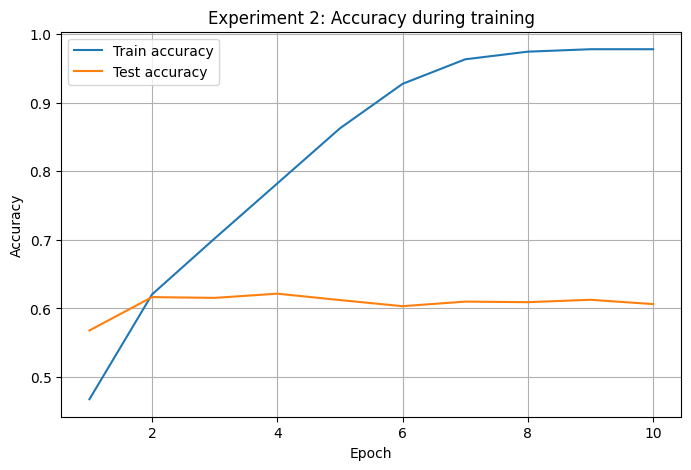

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp2["train_acc"], label="Train accuracy")
plt.plot(epochs, history_exp2["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 2: Accuracy during training")
plt.legend()
plt.grid(True)
plt.show()

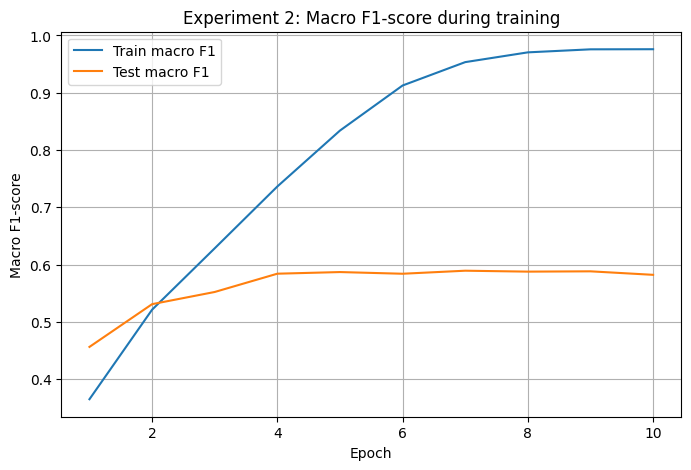

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp2["train_f1"], label="Train macro F1")
plt.plot(epochs, history_exp2["test_f1"], label="Test macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Experiment 2: Macro F1-score during training")
plt.legend()
plt.grid(True)
plt.show()

## 9. Эксперимент 3: добавление регуляризации weight decay

**Конфигурация:**
- модель: MobileNetV2;
- learning rate: 0.001;
- weight decay: 1e-4;
- batch size: 64;
- epochs: 10.


In [ ]:

model_exp3 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model_exp3.classifier[1] = nn.Linear(model_exp3.classifier[1].in_features, num_classes)
model_exp3 = model_exp3.to(device)

criterion_exp3 = nn.CrossEntropyLoss()

optimizer_exp3 = optim.Adam(
    model_exp3.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Experiment 3")
print("Model: MobileNetV2")
print("Learning rate: 0.001")
print("Weight decay: 1e-4")
print("Batch size: 64")
print("Epochs: 10")


Experiment 3
Model: MobileNetV2
Learning rate: 0.001
Weight decay: 1e-4
Batch size: 64
Epochs: 10


In [ ]:
num_epochs = 10

history_exp3 = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model_exp3, train_loader, criterion_exp3, optimizer_exp3, device
    )

    test_loss, test_acc, test_f1 = evaluate(
        model_exp3, test_loader, criterion_exp3, device
    )

    history_exp3["train_loss"].append(train_loss)
    history_exp3["train_acc"].append(train_acc)
    history_exp3["train_f1"].append(train_f1)
    history_exp3["test_loss"].append(test_loss)
    history_exp3["test_acc"].append(test_acc)
    history_exp3["test_f1"].append(test_f1)

    print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}, f1: {train_f1:.4f}")
    print(f"Test  loss: {test_loss:.4f}, acc: {test_acc:.4f}, f1: {test_f1:.4f}")


Epoch 1/10


Validation/Test: 100%|██████████| 113/113 [00:16<00:00,  6.87it/s]


Train loss: 1.1776, acc: 0.5492, f1: 0.4662
Test  loss: 1.0778, acc: 0.5834, f1: 0.5142

Epoch 2/10


Validation/Test: 100%|██████████| 113/113 [00:16<00:00,  6.85it/s]


Train loss: 0.9718, acc: 0.6371, f1: 0.5839
Test  loss: 0.9860, acc: 0.6368, f1: 0.5876

Epoch 3/10


...

Train loss: 0.5642, acc: 0.7948, f1: 0.7829
Test  loss: 1.0776, acc: 0.6443, f1: 0.6115

Epoch 9/10


Validation/Test: 100%|██████████| 113/113 [00:15<00:00,  7.11it/s]


Train loss: 0.5115, acc: 0.8128, f1: 0.7991
Test  loss: 1.1464, acc: 0.6428, f1: 0.6052

Epoch 10/10


Validation/Test: 100%|██████████| 113/113 [00:16<00:00,  6.85it/s]

Train loss: 0.4574, acc: 0.8322, f1: 0.8182
Test  loss: 1.2635, acc: 0.6279, f1: 0.6008


### 9.1. Кривые обучения для эксперимента 3


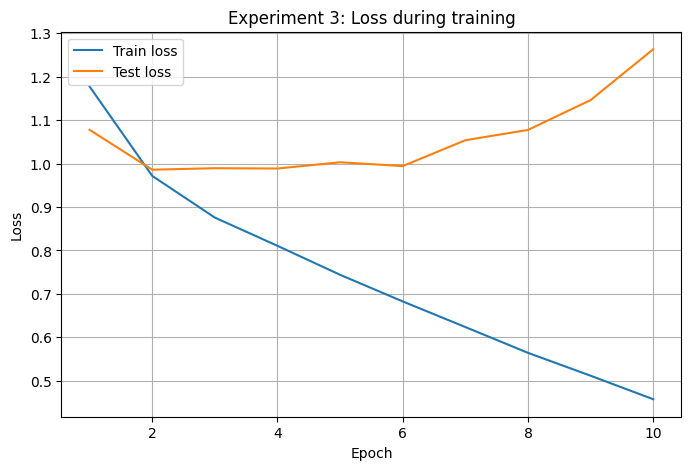

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp3["train_loss"], label="Train loss")
plt.plot(epochs, history_exp3["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3: Loss during training")
plt.legend()
plt.grid(True)
plt.show()

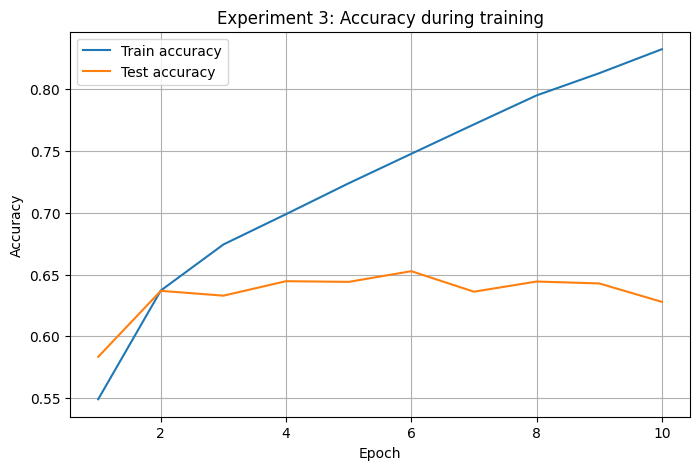

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp3["train_acc"], label="Train accuracy")
plt.plot(epochs, history_exp3["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 3: Accuracy during training")
plt.legend()
plt.grid(True)
plt.show()

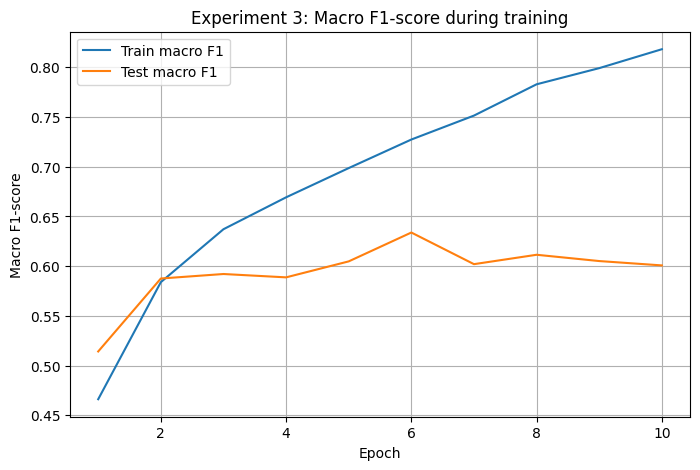

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_exp3["train_f1"], label="Train macro F1")
plt.plot(epochs, history_exp3["test_f1"], label="Test macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Experiment 3: Macro F1-score during training")
plt.legend()
plt.grid(True)
plt.show()

## 10. Матрица несоответствий

Для анализа ошибок используется модель из эксперимента 3, так как она показала лучший macro F1-score.  


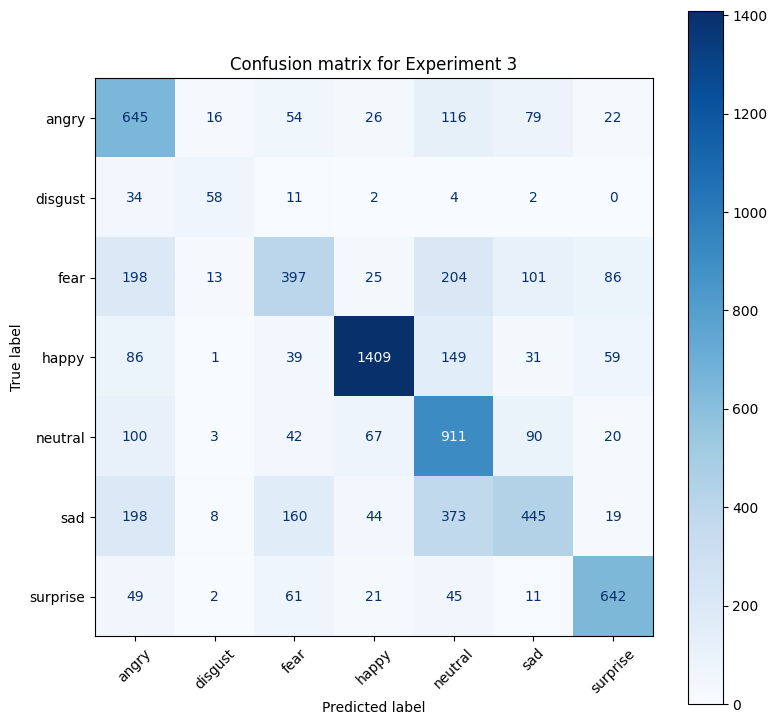

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model_exp3.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting predictions"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_exp3(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion matrix for Experiment 3")
plt.tight_layout()
plt.show()


## 11. Итоговая таблица результатов

В таблице фиксируются лучшие значения метрик на тестовой выборке для каждого эксперимента.


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "model": ["MobileNetV2", "MobileNetV2", "MobileNetV2"],
    "learning_rate": [0.001, 0.0001, 0.001],
    "weight_decay": [0, 0, 1e-4],
    "best_test_accuracy": [0.6567, 0.6215, 0.6527],
    "best_test_macro_f1": [0.6302, 0.5892, 0.6338]
})

results


,experiment,model,learning_rate,weight_decay,best_test_accuracy,best_test_macro_f1
0,Exp 1,MobileNetV2,0.0010,0.0000,0.6567,0.6302
1,Exp 2,MobileNetV2,0.0001,0.0000,0.6215,0.5892
2,Exp 3,MobileNetV2,0.0010,0.0001,0.6527,0.6338


In [ ]:
results.to_csv("experiment_results.csv", index=False)
print("Results saved to experiment_results.csv")


## 12. Сохранение модели

Сохраняются веса модели из эксперимента 3.  


In [ ]:
torch.save(model_exp3.state_dict(), "mobilenetv2_fer2013_exp3.pth")
print("Model weights saved to mobilenetv2_fer2013_exp3.pth")
